In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:]  # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2)

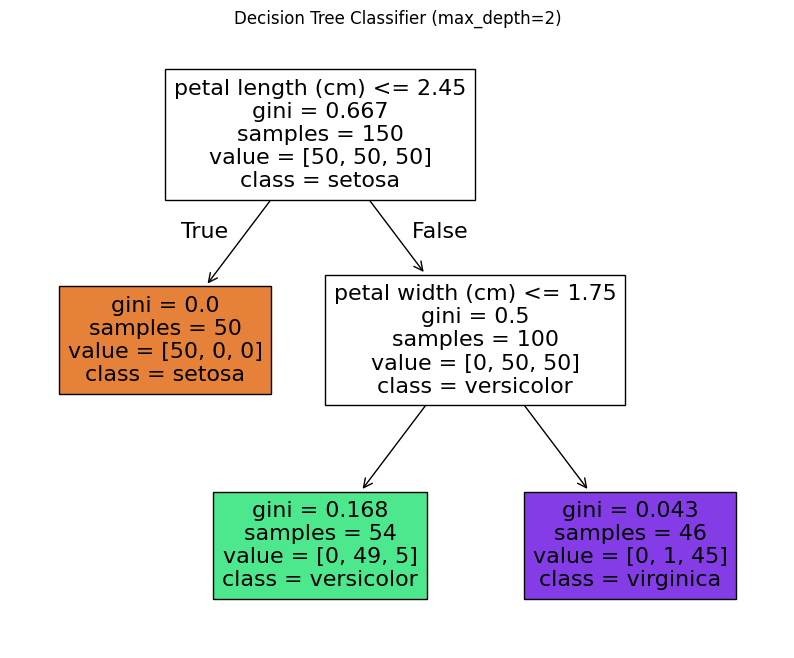

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled=True, feature_names=iris.feature_names[2:], class_names=iris.target_names)
plt.title("Decision Tree Classifier (max_depth=2)")
plt.show()

## Plotting Decision Boundaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

plot_step = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                     np.arange(y_min, y_max, plot_step))

In [ ]:
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])

In [ ]:
X_class_0 = np.c_[xx.ravel(), yy.ravel()][Z == 0]
X_class_1 = np.c_[xx.ravel(), yy.ravel()][Z == 1]
X_class_2 = np.c_[xx.ravel(), yy.ravel()][Z == 2]

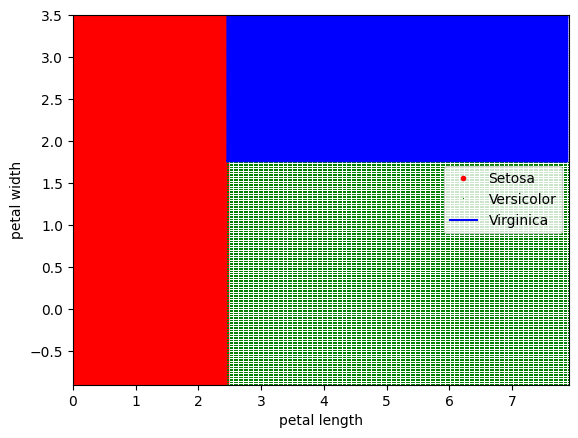

In [ ]:
# plot the graph using matplotlib.pyplot.plot()
plt.axis([x_min, x_max, y_min, y_max])
plt.plot(X_class_0[:,0], X_class_0[:,1], 'r.', label='Setosa')
plt.plot(X_class_1[:,0], X_class_1[:,1], 'g,', label='Versicolor')
plt.plot(X_class_2[:,0], X_class_2[:,1], 'b', label='Virginica')

plt.xlabel('petal length')
plt.ylabel('petal width')
plt.legend()
plt.show()

In [ ]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [ ]:
tree_clf.predict([[5, 1.5]])

array([1])

## Regularisation Hyperparameters

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# generate quadratic random data
m = 100
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(m, 1)

tree_reg = DecisionTreeRegressor()
tree_reg_dept_1 = DecisionTreeRegressor(max_depth=1)
tree_reg_dept_2 = DecisionTreeRegressor(max_depth=2)
tree_reg_dept_3 = DecisionTreeRegressor(max_depth=3)

tree_reg.fit(x, y)
tree_reg_dept_1.fit(x, y)
tree_reg_dept_2.fit(x, y)
tree_reg_dept_3.fit(x, y)

DecisionTreeRegressor(max_depth=3)

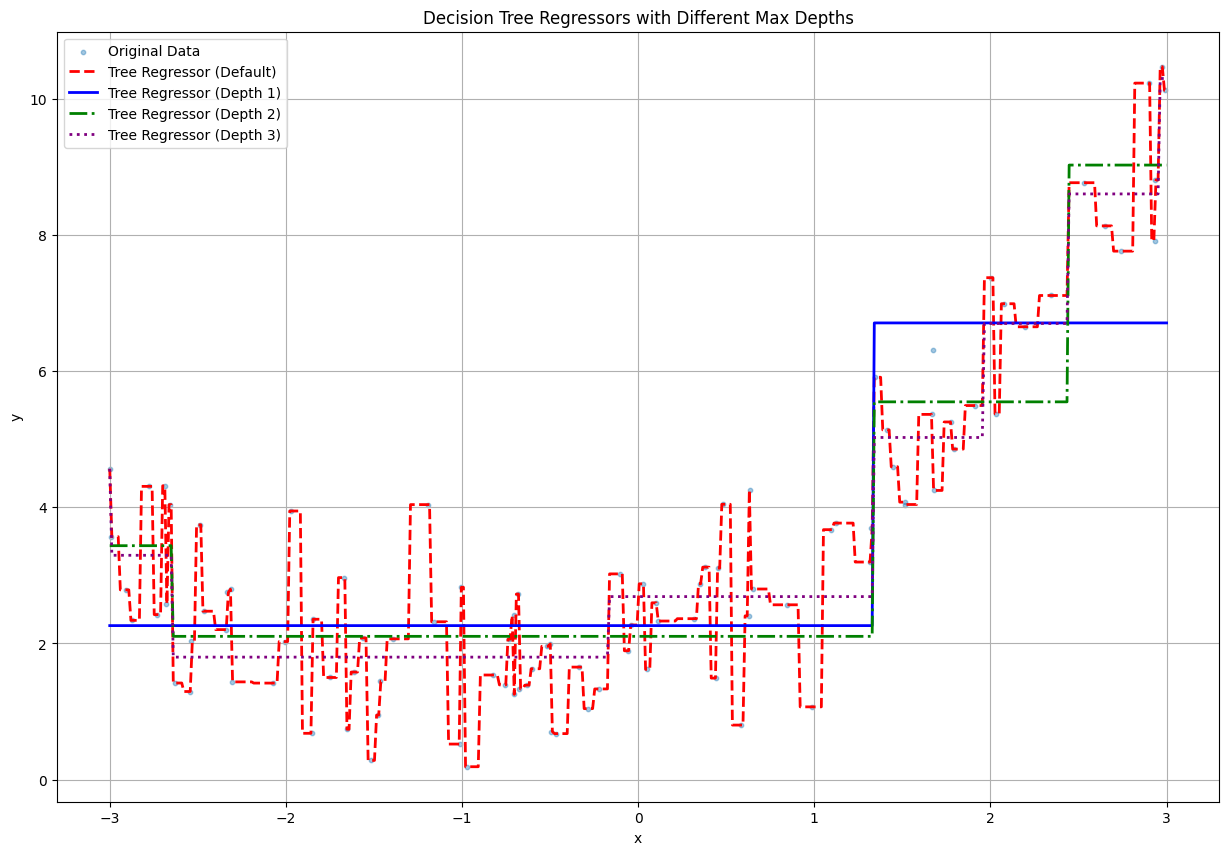

In [ ]:
import matplotlib.pyplot as plt

# Create a range of x values to plot the regression lines
x_plot = np.linspace(-3, 3, 500).reshape(-1, 1)

# Make predictions with each regressor
y_pred = tree_reg.predict(x_plot)
y_pred_dept_1 = tree_reg_dept_1.predict(x_plot)
y_pred_dept_2 = tree_reg_dept_2.predict(x_plot)
y_pred_dept_3 = tree_reg_dept_3.predict(x_plot)

# Create the plot
plt.figure(figsize=(15, 10))

# Plot original data
plt.scatter(x, y, label='Original Data', s=10, alpha=0.4)

# Plot predictions from each regressor with improved contrast
plt.plot(x_plot, y_pred, color='red', linestyle='--', linewidth=2, label='Tree Regressor (Default)')
plt.plot(x_plot, y_pred_dept_1, color='blue', linestyle='-', linewidth=2, label='Tree Regressor (Depth 1)')
plt.plot(x_plot, y_pred_dept_2, color='green', linestyle='-.', linewidth=2, label='Tree Regressor (Depth 2)')
plt.plot(x_plot, y_pred_dept_3, color='purple', linestyle=':', linewidth=2, label='Tree Regressor (Depth 3)')

plt.title('Decision Tree Regressors with Different Max Depths')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing Decision Tree Regressors

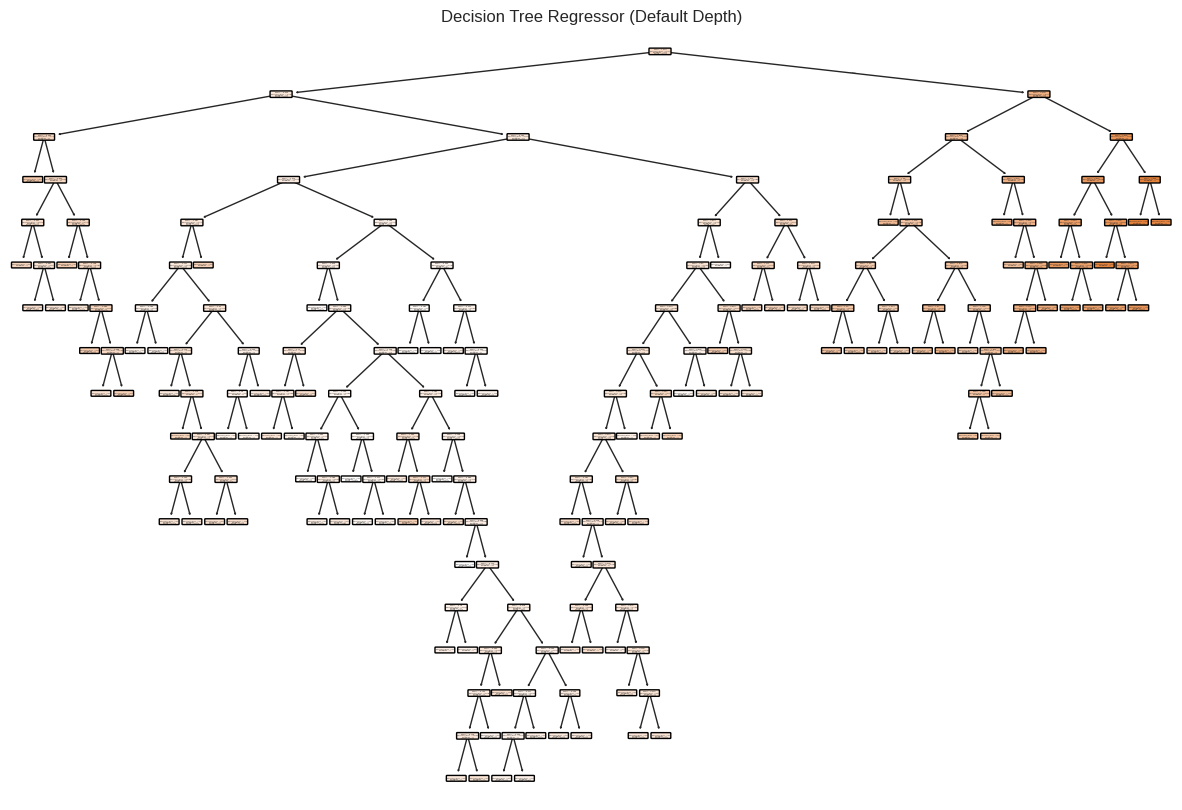

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_reg, filled=True, rounded=True)
plt.title("Decision Tree Regressor (Default Depth)")
plt.show()

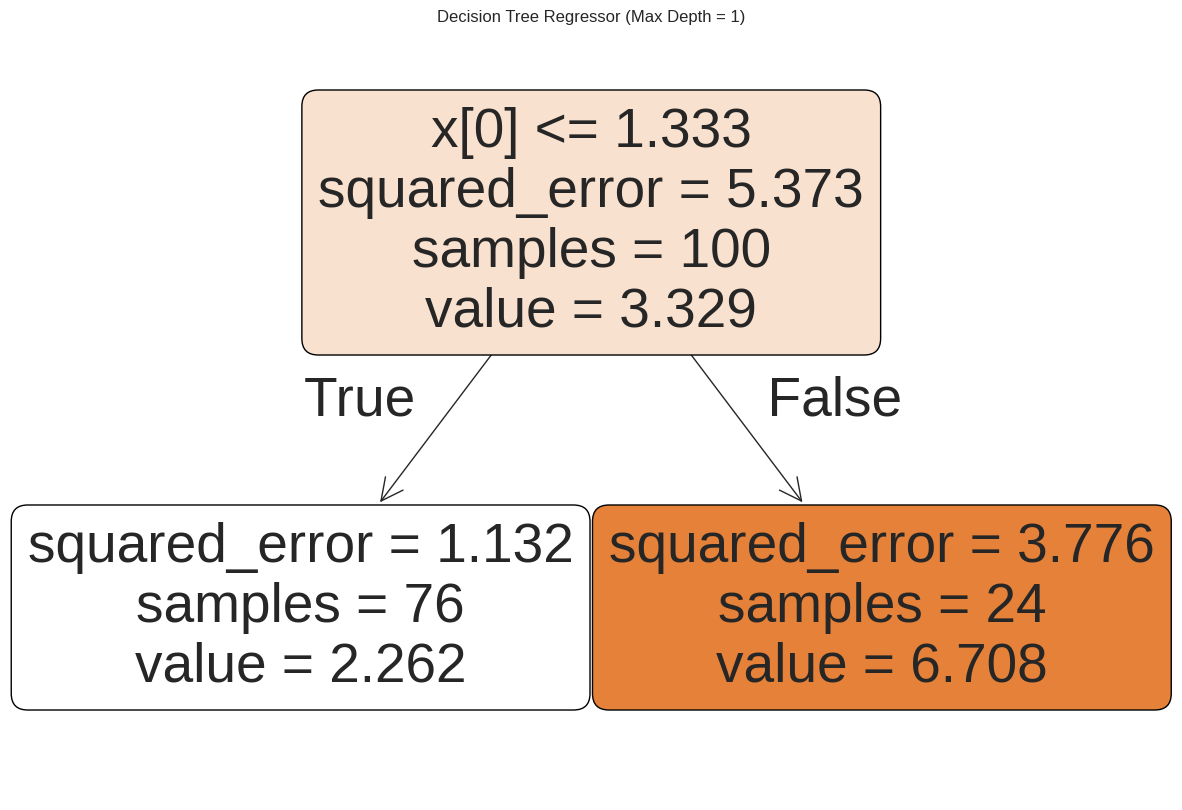

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_reg_dept_1, filled=True, rounded=True)
plt.title("Decision Tree Regressor (Max Depth = 1)")
plt.show()

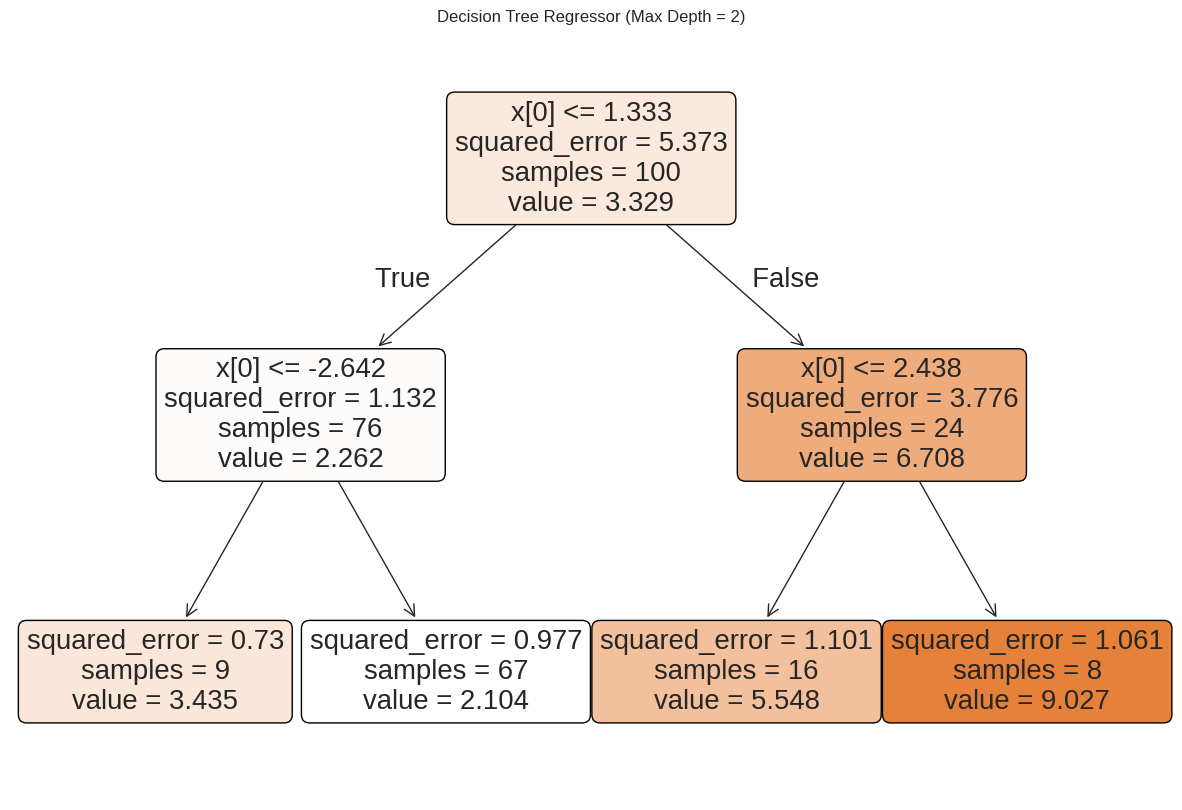

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_reg_dept_2, filled=True, rounded=True)
plt.title("Decision Tree Regressor (Max Depth = 2)")
plt.show()

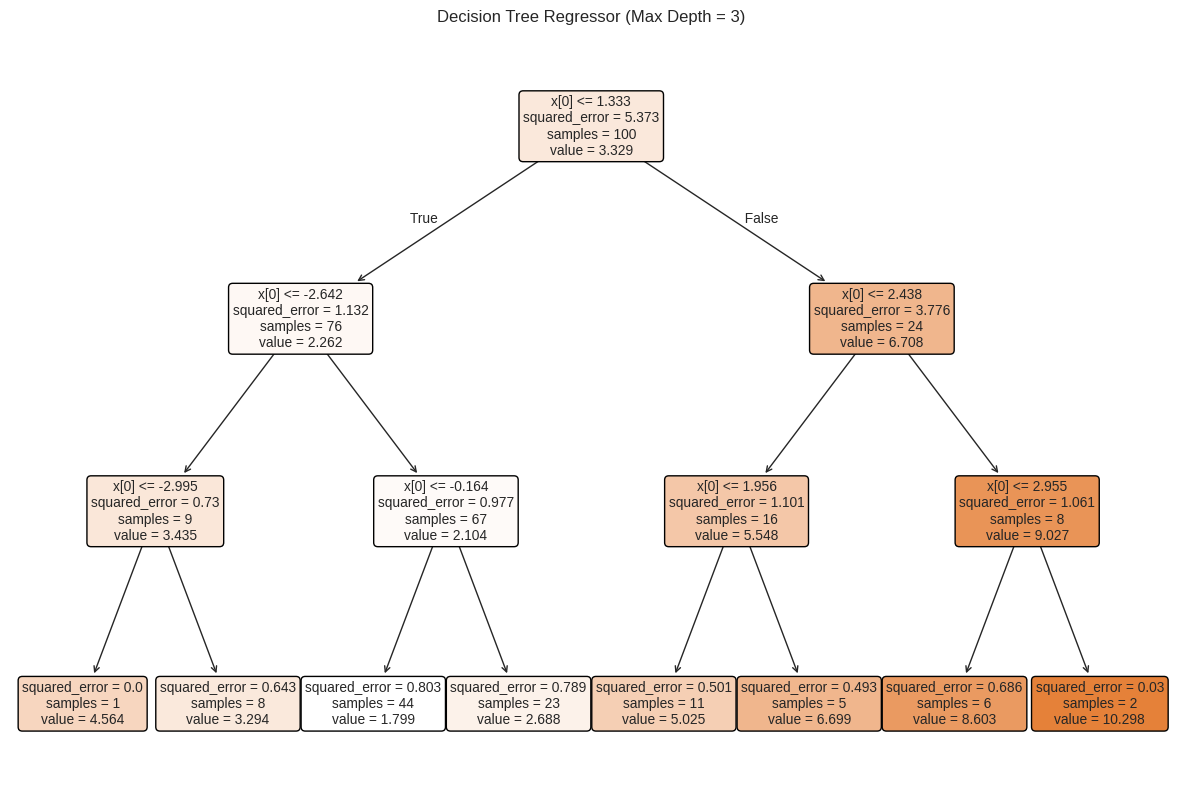

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree_reg_dept_3, filled=True, rounded=True)
plt.title("Decision Tree Regressor (Max Depth = 3)")
plt.show()